# 04 - Bidding Evaluation: Newsvendor + DR-Pinson (Multi-Site, basiert auf NB03)

Konsumiert `predictions_{plant}.csv` (NB03): y_true + Point (persistence/elastic_net) + Quantile xgb/qgb/qrf q10-q90.

**Strategien:** Point | Median q50 | tau* statisch | tau* dynamisch (Pinson) | DR-T1 (Wasserstein) | DR-T2 (Bernoulli) | Oracle

**Szenarien:** pro Standort + Portfolio (Summe, nur Stunden mit allen Standorten).  
ARIMA ausgeschlossen (3-Monats-Gate: == Persistence).

In [34]:
from __future__ import annotations
from pathlib import Path
import sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.load_data import load_rebap
from src.bidding.newsvendor import compute_costs, optimal_quantile, loss, profit

MARKT_DIR    = PROJECT_ROOT / "data" / "raw" / "Daten zu Marktpreisen"
FORECAST_DIR = PROJECT_ROOT / "results" / "forecasts"
TABLES_DIR   = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR  = PROJECT_ROOT / "results" / "figures"
for d in [TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print("Setup OK")

Setup OK


## 1. NB03-Forecasts + Preise laden

In [35]:
PLANTS = ["Schonungen", "Schwanfeld", "Trabelsdorf", "Obbach"]
parts = []
for p in PLANTS:
    fp = FORECAST_DIR / f"predictions_{p.lower()}.csv"
    if fp.exists():
        parts.append(pd.read_csv(fp, parse_dates=["timestamp"]))
fc = pd.concat(parts, ignore_index=True)
print("Forecasts:", fc.shape, "| Sites:", sorted(fc["site"].unique()))

rebap_hourly = load_rebap()[["timestamp", "rebap"]]
da = pd.read_csv(MARKT_DIR / "prices_standardized.csv", sep=";", decimal=",")
da["timestamp"] = pd.to_datetime(da["Datum von"], format="%d.%m.%Y %H:%M", errors="coerce")
da["da_price"]  = pd.to_numeric(da["Preis"], errors="coerce")
da_prices = da[["timestamp", "da_price"]].dropna()
print("reBAP:", rebap_hourly.shape, "| DA:", da_prices.shape)

for p in PLANTS:
    fp = FORECAST_DIR / f"predictions_{p.lower()}.csv"
    if fp.exists():
        tmp = pd.read_csv(fp, parse_dates=["timestamp"])
        tmp["site"] = p  # site-Spalte ergänzen
        parts.append(tmp)

Forecasts: (230307, 26) | Sites: ['Obbach', 'Schonungen', 'Schwanfeld', 'Trabelsdorf']
Lade 10 reBAP-Dateien...
reBAP: 87,672 Stunden | 2016-01-01 bis 2025-12-31
reBAP: (87672, 2) | DA: (87662, 2)


## 2. Kostenstruktur (kein Leakage: nur Trainingspreise)

In [36]:
TEST_START = fc["timestamp"].min()
print("Forecast period:", TEST_START, "->", fc["timestamp"].max())

prices = rebap_hourly.merge(da_prices, on="timestamp", how="inner").sort_values("timestamp").reset_index(drop=True)
train_prices = prices[prices["timestamp"] < TEST_START]
if len(train_prices) < 168:
    train_prices = prices.iloc[:len(prices)//5]   # Fallback: erste 20%
c_under, c_over = compute_costs(train_prices["da_price"].to_numpy(), train_prices["rebap"].to_numpy())
tau_star = optimal_quantile(c_under, c_over) if (c_under + c_over) > 0 else 0.5
print(f"c_under={c_under:.4f}  c_over={c_over:.4f}  tau_star={tau_star:.4f}")

WINDOW = 30 * 24
prices["c_under_roll"] = np.maximum(prices["rebap"] - prices["da_price"], 0).shift(1).rolling(WINDOW, min_periods=168).mean()
prices["c_over_roll"]  = np.maximum(prices["da_price"] - prices["rebap"], 0).shift(1).rolling(WINDOW, min_periods=168).mean()
prices["tau_dyn"] = (prices["c_under_roll"] / (prices["c_under_roll"] + prices["c_over_roll"])).clip(0.01, 0.99)

s_train = (train_prices["rebap"].to_numpy() > train_prices["da_price"].to_numpy()).astype(float)
tau_hat_s = float(s_train.mean()); n_s = len(s_train)
se_tau = float(np.sqrt(tau_hat_s * (1 - tau_hat_s) / n_s)) if n_s > 0 else 0.0
tau_U = float(np.clip(tau_hat_s + 1.645 * se_tau, 0.01, 0.99))
print(f"DR-T2: tau_hat_s={tau_hat_s:.4f}  tau_U={tau_U:.4f}")

Forecast period: 2017-01-31 00:00:00 -> 2025-08-31 23:00:00
c_under=12.8180  c_over=10.7937  tau_star=0.5429
DR-T2: tau_hat_s=0.5890  tau_U=0.5973


## 3. Bidding-Funktionen

In [37]:
QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]
PROB_MODELS  = {"xgb": "XGBoost", "qgb": "QGB", "qrf": "QRF", "qr": "Quantile_Regression"}
POINT_MODELS = {"persistence": "Persistence", "elastic_net": "Elastic_Net"}

def evaluate_bid(name, bid, y, p_da, p_rebap, cu, co):
    bid = np.clip(bid, 0, None)
    nv = loss(bid, y, cu, co); pr = profit(bid, y, p_da, p_rebap)
    return {"model": name,
            "mean_profit": float(np.mean(pr)), "total_profit": float(np.sum(pr)),
            "mean_nv_loss": float(np.mean(nv)), "total_nv_loss": float(np.sum(nv)),
            "mean_abs_imbalance": float(np.mean(np.abs(bid - y))),
            "underbid_ratio": float(np.mean(bid > y)), "overbid_ratio": float(np.mean(bid < y))}

def qbid(d, prefix, tau):
    exact = f"{prefix}_q{int(tau * 100):02d}"
    if exact in d.columns:
        return d[exact].to_numpy()
    lo = max((q for q in QUANTILES if q <= tau), default=QUANTILES[0])
    hi = min((q for q in QUANTILES if q >= tau), default=QUANTILES[-1])
    if lo == hi:
        return d[f"{prefix}_q{int(lo * 100):02d}"].to_numpy()
    w = (tau - lo) / (hi - lo)
    return (1 - w) * d[f"{prefix}_q{int(lo * 100):02d}"].to_numpy() + w * d[f"{prefix}_q{int(hi * 100):02d}"].to_numpy()

def qbid_dyn(d, prefix, tau_arr):
    cols = [f"{prefix}_q{int(q * 100):02d}" for q in QUANTILES]
    Q = d[cols].to_numpy(); ta = np.clip(tau_arr, QUANTILES[0], QUANTILES[-1])
    bids = np.zeros(len(ta))
    for j in range(len(QUANTILES) - 1):
        lo, hi = QUANTILES[j], QUANTILES[j + 1]
        m = (ta >= lo) & (ta < hi)
        if m.any():
            w = (ta[m] - lo) / (hi - lo)
            bids[m] = (1 - w) * Q[m, j] + w * Q[m, j + 1]
    bids[ta >= QUANTILES[-1]] = Q[ta >= QUANTILES[-1], -1]
    return bids

def dr_t1_bid(d, prefix, tau_hat, eps):
    iqr = (d[f"{prefix}_q75"] - d[f"{prefix}_q25"]).to_numpy()
    sigma = np.maximum(iqr / 1.35, 1e-6)
    qn = qbid(d, prefix, tau_hat)
    qx = d[f"{prefix}_q90"].to_numpy() if tau_hat >= 0.5 else d[f"{prefix}_q10"].to_numpy()
    w = np.clip(eps / sigma, 0.0, 1.0)
    return (1 - w) * qn + w * qx

print("Bidding functions ready")

Bidding functions ready


## 4. run_bidding (ein Szenario)

In [38]:
def run_bidding(df_fc, scenario):
    d = df_fc.merge(prices[["timestamp", "rebap", "da_price"]], on="timestamp", how="inner").reset_index(drop=True)
    if len(d) == 0:
        warnings.warn(f"{scenario}: keine Preis-Ueberlappung"); return []
    y = d["y_true"].to_numpy()
    p_da, p_rebap = d["da_price"].to_numpy(), d["rebap"].to_numpy()
    tau_dyn = d.merge(prices[["timestamp", "tau_dyn"]], on="timestamp", how="left")["tau_dyn"].fillna(tau_star).to_numpy()
    res = []
    for col, name in POINT_MODELS.items():
        if col in d.columns:
            res.append({**evaluate_bid(name, d[col].to_numpy(), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
    for prefix, name in PROB_MODELS.items():
        res.append({**evaluate_bid(f"{name} (q50)", qbid(d, prefix, 0.5), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
        res.append({**evaluate_bid(f"{name} (tau* stat)", qbid(d, prefix, tau_star), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
        res.append({**evaluate_bid(f"{name} (tau* dyn)", qbid_dyn(d, prefix, tau_dyn), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
        res.append({**evaluate_bid(f"{name} (DR-T1 eps=0.2)", dr_t1_bid(d, prefix, tau_star, 0.20), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
        res.append({**evaluate_bid(f"{name} (DR-T2 tau_U)", qbid(d, prefix, tau_U), y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
    res.append({**evaluate_bid("Oracle", y, y, p_da, p_rebap, c_under, c_over), "scenario": scenario})
    return res

print("run_bidding ready")

run_bidding ready


## 5. Alle Szenarien: pro Standort + Portfolio

In [39]:
SITES = sorted(fc["site"].unique())
all_results = []
for site in SITES:
    r = run_bidding(fc[fc["site"] == site].copy(), site)
    all_results.extend(r)
    print(f"{site:<12} {len(fc[fc['site']==site])} rows -> {len(r)} strategies")

# Portfolio: Summe ueber Standorte je Stunde (nur Stunden mit allen Standorten -> 4-Site-Portfolio)
num_cols = [c for c in fc.columns if c not in ("site", "timestamp")]
counts = fc.groupby("timestamp").size()
full_ts = counts[counts == len(SITES)].index
portfolio = fc[fc["timestamp"].isin(full_ts)].groupby("timestamp", as_index=False)[num_cols].sum()
r = run_bidding(portfolio, "Portfolio")
all_results.extend(r)
print(f"{'Portfolio':<12} {len(portfolio)} rows (alle {len(SITES)} Sites) -> {len(r)} strategies")

results_df = pd.DataFrame(all_results)[
    ["scenario", "model", "mean_nv_loss", "total_nv_loss", "mean_profit", "total_profit",
     "mean_abs_imbalance", "underbid_ratio", "overbid_ratio"]
]
results_df.to_csv(TABLES_DIR / "bidding_results.csv", index=False)
print("Saved bidding_results.csv:", results_df.shape)

Obbach       8040 rows -> 23 strategies
Schonungen   74313 rows -> 23 strategies
Schwanfeld   74933 rows -> 23 strategies
Trabelsdorf  73021 rows -> 23 strategies
Portfolio    7847 rows (alle 4 Sites) -> 23 strategies
Saved bidding_results.csv: (115, 9)


## 6. Beste Strategie je Szenario + Portfolio-Ranking

In [40]:
print("=== Beste Nicht-Oracle-Strategie je Szenario (mean NV loss) ===")
for sc in results_df["scenario"].unique():
    sub = results_df[(results_df["scenario"] == sc) & (results_df["model"] != "Oracle")]
    best = sub.loc[sub["mean_nv_loss"].idxmin()]
    print(f"  {sc:<12} best={best['model']:<28} NV={best['mean_nv_loss']:.3f}")
print()
print("=== Portfolio: alle Strategien sortiert ===")
port = results_df[results_df["scenario"] == "Portfolio"].sort_values("mean_nv_loss")
print(port[["model", "mean_nv_loss", "mean_profit"]].to_string(index=False))

=== Beste Nicht-Oracle-Strategie je Szenario (mean NV loss) ===
  Obbach       best=QGB (q50)                    NV=3.724
  Schonungen   best=QGB (q50)                    NV=1.996
  Schwanfeld   best=QGB (q50)                    NV=3.749
  Trabelsdorf  best=QGB (q50)                    NV=3.188
  Portfolio    best=QRF (q50)                    NV=10.498

=== Portfolio: alle Strategien sortiert ===
                              model  mean_nv_loss  mean_profit
                             Oracle      0.000000   220.365553
                          QRF (q50)     10.498331   225.092749
                    QRF (tau* stat)     10.660562   224.841345
                          QGB (q50)     10.723767   224.560410
                     QRF (tau* dyn)     10.754289   225.157543
                    QGB (tau* stat)     10.840963   223.878431
                  QRF (DR-T2 tau_U)     11.035650   224.522229
                      XGBoost (q50)     11.092727   225.382226
                XGBoost (tau* sta

## 7. Plot: Portfolio NV-Loss je Strategie

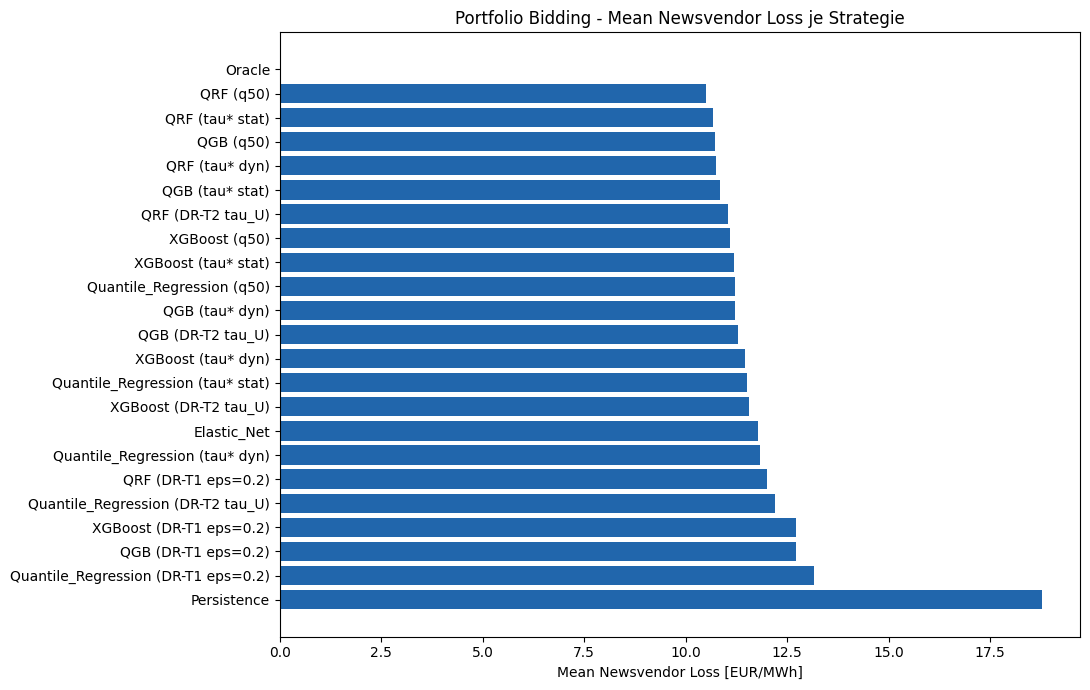

Saved figure


In [41]:
port = results_df[results_df["scenario"] == "Portfolio"].sort_values("mean_nv_loss")
fig, ax = plt.subplots(figsize=(11, 7))
colors = ["#888888" if m == "Oracle" else "#2166ac" for m in port["model"]]
ax.barh(port["model"], port["mean_nv_loss"], color=colors)
ax.set_xlabel("Mean Newsvendor Loss [EUR/MWh]")
ax.set_title("Portfolio Bidding - Mean Newsvendor Loss je Strategie")
ax.invert_yaxis(); plt.tight_layout()
plt.savefig(FIGURES_DIR / "bidding_portfolio_nvloss.png", dpi=150); plt.show()
print("Saved figure")

## 8. Forecast-Genauigkeit (MAE / Pinball)

In [42]:
# Forecast-Genauigkeit je Modell (MAE + mean Pinball)
from sklearn.metrics import mean_absolute_error
pb = pd.read_csv(TABLES_DIR / "pinball_evaluation.csv")
pb_mean = pb.groupby("model")["pinball_loss"].mean()  # Mittel über alle Quantile und Standorte
print(pb_mean.sort_values())
acc_rows = []
for site in SITES:
    d = fc[fc["site"] == site]; y = d["y_true"].values
    for col, name in [("persistence", "Persistence"), ("elastic_net", "Elastic_Net")]:
        acc_rows.append({"model": name, "MAE": mean_absolute_error(y, d[col].values)})
    for mdl, name in PROB_MODELS.items():
        acc_rows.append({"model": name, "MAE": mean_absolute_error(y, d[f"{mdl}_q50"].values)})
acc_df = pd.DataFrame(acc_rows).groupby("model")["MAE"].mean().reset_index()
acc_df["Pinball"] = acc_df["model"].map({"XGBoost": pb_mean.get("xgb"), "QGB": pb_mean.get("qgb"), "QRF": pb_mean.get("qrf")})
print("Forecast-Genauigkeit (Mittel ueber Standorte):")
print(acc_df.round(4).to_string(index=False))

model
qgb    0.098434
xgb    0.100269
qr     0.101352
qrf    0.102273
Name: pinball_loss, dtype: float64
Forecast-Genauigkeit (Mittel ueber Standorte):
              model    MAE  Pinball
        Elastic_Net 0.3016      NaN
        Persistence 0.4561      NaN
                QGB 0.2731   0.0984
                QRF 0.2758   0.1023
Quantile_Regression 0.2898      NaN
            XGBoost 0.2790   0.1003


## 9. Decision-aware: Genauigkeit vs. oekonomischer Wert

              model    MAE  Pinball  econ_nv_loss
        Elastic_Net 0.3016      NaN        2.1567
        Persistence 0.4561      NaN        3.7707
                QGB 0.2731   0.0984        1.9959
                QRF 0.2758   0.1023        2.0182
Quantile_Regression 0.2898      NaN        2.0101
            XGBoost 0.2790   0.1003        2.0536

Spearman(MAE, NV-Loss) = 0.829
Bestes nach Genauigkeit: QGB  |  Bestes oekonomisch: QGB
-> identisch


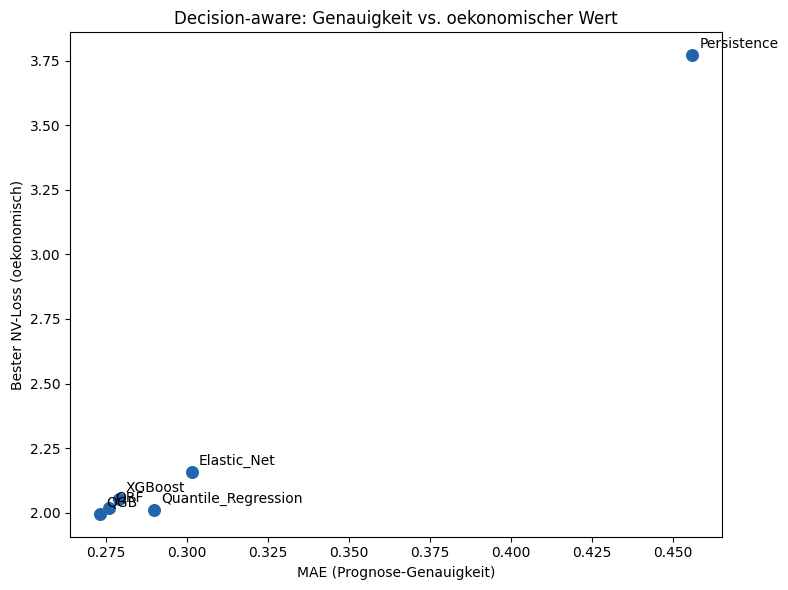

In [43]:
# Decision-aware: Genauigkeit vs. oekonomischer Wert
def base_model(m):
    for k in ["Persistence", "Elastic_Net", "Quantile_Regression", "XGBoost", "QGB", "QRF"]:
        if m.startswith(k): return k
    return m
econ = results_df[(results_df["model"] != "Oracle") & (results_df["scenario"] != "Portfolio")].copy()
econ["base"] = econ["model"].apply(base_model)
econ_best = econ.groupby("base")["mean_nv_loss"].min().reset_index().rename(columns={"base": "model", "mean_nv_loss": "econ_nv_loss"})
merged = acc_df.merge(econ_best, on="model", how="inner")

def spearman(a, b):
    ra = pd.Series(a).rank().values; rb = pd.Series(b).rank().values
    return float(np.corrcoef(ra, rb)[0, 1])
rho = spearman(merged["MAE"], merged["econ_nv_loss"])
best_acc = merged.loc[merged["MAE"].idxmin(), "model"]
best_econ = merged.loc[merged["econ_nv_loss"].idxmin(), "model"]
print(merged.round(4).to_string(index=False))
print(f"\nSpearman(MAE, NV-Loss) = {rho:.3f}")
print(f"Bestes nach Genauigkeit: {best_acc}  |  Bestes oekonomisch: {best_econ}")
print("-> identisch" if best_acc == best_econ else "-> DIVERGENZ: decision-aware Auswahl waehlt ein anderes Modell!")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged["MAE"], merged["econ_nv_loss"], s=70, color="#2166ac")
for _, r in merged.iterrows():
    ax.annotate(r["model"], (r["MAE"], r["econ_nv_loss"]), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("MAE (Prognose-Genauigkeit)"); ax.set_ylabel("Bester NV-Loss (oekonomisch)")
ax.set_title("Decision-aware: Genauigkeit vs. oekonomischer Wert")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "decision_aware_accuracy_vs_economics.png", dpi=150); plt.show()

## 10. Interpretierbar vs. Black-Box

                   min   mean
group                        
black-box        1.996  2.023
interpretierbar  2.010  2.646

Hinweis: interpretierbar aktuell nur Point (Elastic Net). Lineare Quantile Regression
(interpretierbar + probabilistisch) folgt in NB03 -> dann fairer Vergleich auf Quantil-Ebene.


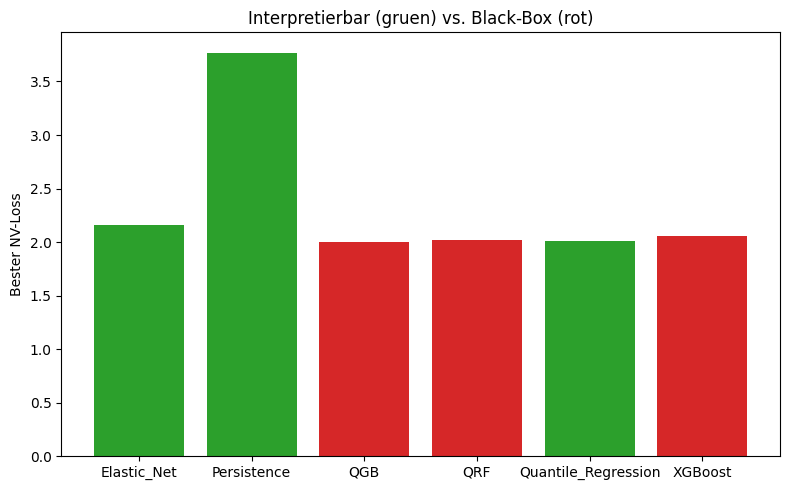

In [44]:
# Interpretierbar vs. Black-Box (oekonomisch)
GROUPS = {"Persistence": "interpretierbar", "Elastic_Net": "interpretierbar", "Quantile_Regression": "interpretierbar",
          "XGBoost": "black-box", "QGB": "black-box", "QRF": "black-box"}
econ_best["group"] = econ_best["model"].map(GROUPS)
print(econ_best.groupby("group")["econ_nv_loss"].agg(["min", "mean"]).round(3))
print("\nHinweis: interpretierbar aktuell nur Point (Elastic Net). Lineare Quantile Regression")
print("(interpretierbar + probabilistisch) folgt in NB03 -> dann fairer Vergleich auf Quantil-Ebene.")
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2ca02c" if GROUPS[m] == "interpretierbar" else "#d62728" for m in econ_best["model"]]
ax.bar(econ_best["model"], econ_best["econ_nv_loss"], color=colors)
ax.set_ylabel("Bester NV-Loss"); ax.set_title("Interpretierbar (gruen) vs. Black-Box (rot)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "interpretable_vs_blackbox.png", dpi=150); plt.show()

## 11. Point vs Probabilistic (oekonomisch)

In [45]:
# Point vs Probabilistic (oekonomisch)
point_econ = econ[econ["base"].isin(["Persistence", "Elastic_Net"])].groupby("base")["mean_nv_loss"].min()
prob_econ = econ[econ["base"].isin(["XGBoost", "QGB", "QRF"]) & econ["model"].str.contains("tau")].groupby("base")["mean_nv_loss"].min()
print("Point-Gebote (direkt):"); print(point_econ.round(3))
print("\nProbabilistic (tau*-Gebote):"); print(prob_econ.round(3))
bp, bq = float(point_econ.min()), float(prob_econ.min())
print(f"\nBester Point: {bp:.3f}  |  Bester Probabilistic: {bq:.3f}")
print(f"Oekonomischer Vorteil probabilistisch: {100*(bp-bq)/bp:.1f}% niedrigerer NV-Loss")

Point-Gebote (direkt):
base
Elastic_Net    2.157
Persistence    3.771
Name: mean_nv_loss, dtype: float64

Probabilistic (tau*-Gebote):
base
QGB        2.020
QRF        2.045
XGBoost    2.075
Name: mean_nv_loss, dtype: float64

Bester Point: 2.157  |  Bester Probabilistic: 2.020
Oekonomischer Vorteil probabilistisch: 6.3% niedrigerer NV-Loss


## 12. Risk Exposure + Bidding-Detail

      plant         bid  mean_profit  CVaR5_profit  mean_nv_loss  p95_nv_loss  max_imbalance
     Obbach Elastic_Net       59.284      -110.372         4.168       11.702          3.290
     Obbach    QGB_tau*       58.931      -102.980         3.773       11.391          2.015
 Schonungen Elastic_Net       24.030       -38.721         2.157        6.831          8.045
 Schonungen    QGB_tau*       24.007       -35.382         2.020        6.854          1.919
 Schwanfeld Elastic_Net       43.321       -85.147         4.439       13.663         11.613
 Schwanfeld    QGB_tau*       43.072       -70.079         3.809       12.970          3.022
Trabelsdorf Elastic_Net       40.443       -65.024         3.584       10.579         23.440
Trabelsdorf    QGB_tau*       40.653       -56.998         3.247       10.344          2.965


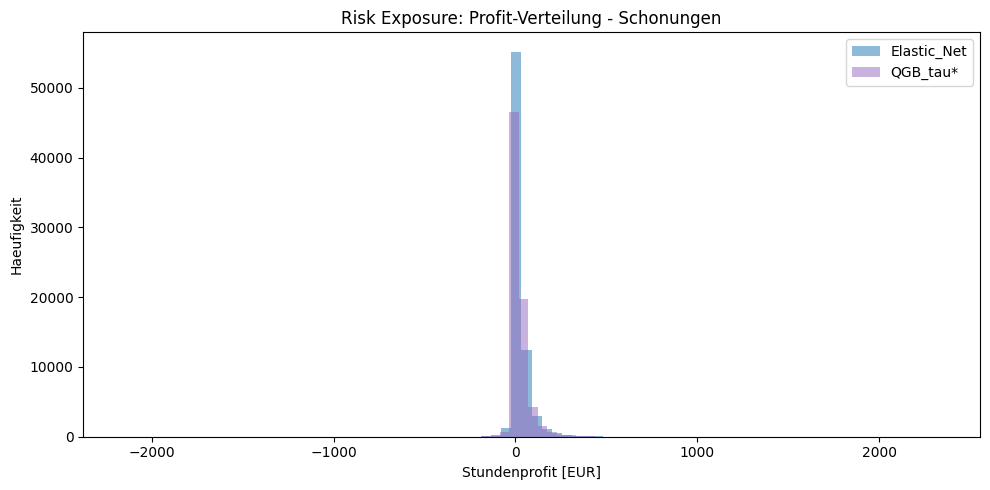

In [46]:
# Risk Exposure + per-Stunde Bidding-Detail speichern (fuer NB05-Fehleranalyse)
risk_rows = []
for site in SITES:
    dd = fc[fc["site"] == site].merge(prices[["timestamp", "rebap", "da_price"]], on="timestamp", how="inner").reset_index(drop=True)
    if len(dd) == 0: continue
    y, p_da, p_re = dd["y_true"].values, dd["da_price"].values, dd["rebap"].values
    for label, bid in [("Elastic_Net", dd["elastic_net"].values), ("QGB_tau*", qbid(dd, "qgb", tau_star))]:
        b = np.clip(bid, 0, None)
        nv = loss(b, y, c_under, c_over); pr = profit(b, y, p_da, p_re)
        k = max(1, int(0.05 * len(pr)))
        risk_rows.append({"plant": site, "bid": label, "mean_profit": pr.mean(),
                          "CVaR5_profit": float(np.sort(pr)[:k].mean()),
                          "mean_nv_loss": nv.mean(), "p95_nv_loss": float(np.percentile(nv, 95)),
                          "max_imbalance": float(np.max(np.abs(b - y)))})
    bidq = np.clip(qbid(dd, "qgb", tau_star), 0, None)
    pd.DataFrame({"timestamp": dd["timestamp"], "y_true": y, "bid": bidq,
                  "nv_loss": loss(bidq, y, c_under, c_over),
                  "q_spread": (dd["qgb_q90"] - dd["qgb_q10"]).values}).to_csv(
        FORECAST_DIR / f"bidding_detail_{site.lower()}.csv", index=False)
risk_df = pd.DataFrame(risk_rows)
risk_df.to_csv(TABLES_DIR / "risk_metrics.csv", index=False)
print(risk_df.round(3).to_string(index=False))

dfp = fc[fc["site"] == "Schonungen"].merge(prices[["timestamp", "rebap", "da_price"]], on="timestamp", how="inner")
y = dfp["y_true"].values
fig, ax = plt.subplots(figsize=(10, 5))
for label, bid, c in [("Elastic_Net", dfp["elastic_net"].values, "#1f77b4"), ("QGB_tau*", qbid(dfp, "qgb", tau_star), "#9467bd")]:
    pr = profit(np.clip(bid, 0, None), y, dfp["da_price"].values, dfp["rebap"].values)
    ax.hist(pr, bins=80, alpha=0.5, label=label, color=c)
ax.set_xlabel("Stundenprofit [EUR]"); ax.set_ylabel("Haeufigkeit")
ax.set_title("Risk Exposure: Profit-Verteilung - Schonungen"); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / "risk_profit_distribution.png", dpi=150); plt.show()

## 13. Cross-Site: Forecast-Genauigkeit (Point | Probabilistic getrennt)

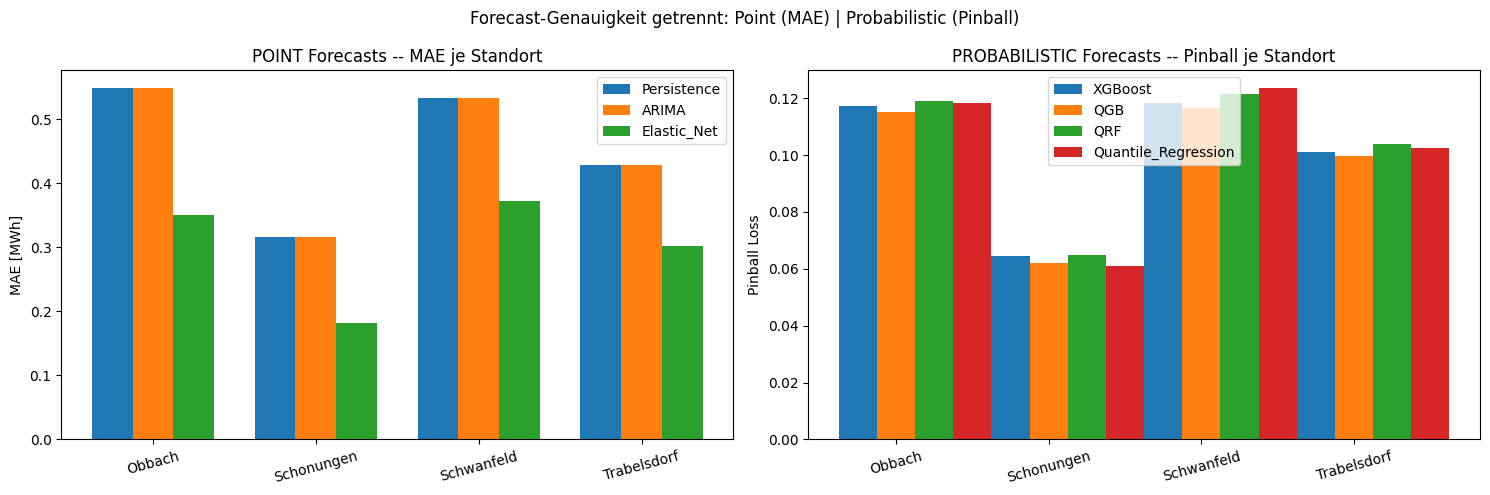

In [47]:
# Cross-Site Forecast-Genauigkeit -- Point (MAE) und Probabilistic (Pinball) GETRENNT
from sklearn.metrics import mean_absolute_error
sites = sorted(fc["site"].unique())
POINT_COLS = {"persistence": "Persistence", "arima": "ARIMA", "elastic_net": "Elastic_Net"}
PROB_LBL = {"xgb": "XGBoost", "qgb": "QGB", "qrf": "QRF", "qr": "Quantile_Regression"}

# Point: MAE je Standort
pt = []
for s in sites:
    d = fc[fc["site"] == s]; y = d["y_true"].values
    for c, n in POINT_COLS.items():
        pt.append({"site": s, "model": n, "MAE": mean_absolute_error(y, d[c].values)})
pt = pd.DataFrame(pt)
# Probabilistic: Pinball je Standort
pb = pd.read_csv(TABLES_DIR / "pinball_evaluation.csv")
pbp = pb.groupby(["plant", "model"])["pinball_loss"].mean().reset_index()
pbp["model"] = pbp["model"].map(PROB_LBL)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(sites)); w = 0.25
for i, (c, n) in enumerate(POINT_COLS.items()):
    vals = [pt[(pt["site"] == s) & (pt["model"] == n)]["MAE"].values[0] for s in sites]
    axes[0].bar(x + (i - 1) * w, vals, w, label=n)
axes[0].set_xticks(x); axes[0].set_xticklabels(sites, rotation=15); axes[0].set_ylabel("MAE [MWh]")
axes[0].set_title("POINT Forecasts -- MAE je Standort"); axes[0].legend()
for i, (c, n) in enumerate(PROB_LBL.items()):
    vals = [pbp[(pbp["plant"] == s) & (pbp["model"] == n)]["pinball_loss"].values[0] if len(pbp[(pbp["plant"] == s) & (pbp["model"] == n)]) else np.nan for s in sites]
    axes[1].bar(x + (i - 1) * w, vals, w, label=n)
axes[1].set_xticks(x); axes[1].set_xticklabels(sites, rotation=15); axes[1].set_ylabel("Pinball Loss")
axes[1].set_title("PROBABILISTIC Forecasts -- Pinball je Standort"); axes[1].legend()
plt.suptitle("Forecast-Genauigkeit getrennt: Point (MAE) | Probabilistic (Pinball)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "crosssite_forecast_accuracy.png", dpi=150); plt.show()

## 14. Cross-Site: Oekonomie (Point vs Probabilistic)

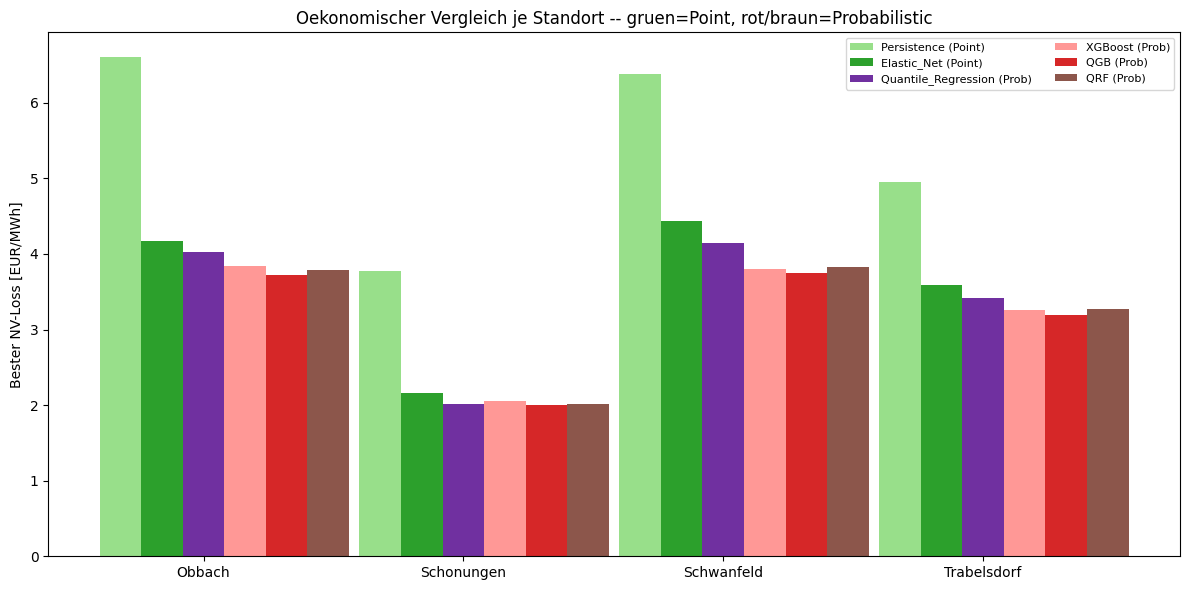

Probabilistische tau*-Gebote (rot/braun) durchgaengig niedrigerer NV-Loss als Point (gruen)


In [48]:
# Cross-Site Oekonomie -- Point vs Probabilistic (kombiniert nur im Bidding-Kontext)
def base_model(m):
    for k in ["Persistence", "Elastic_Net", "Quantile_Regression", "XGBoost", "QGB", "QRF"]:
        if m.startswith(k): return k
    return m
econ2 = results_df[(results_df["model"] != "Oracle") & (results_df["scenario"] != "Portfolio")].copy()
econ2["base"] = econ2["model"].apply(base_model)
best = econ2.groupby(["scenario", "base"])["mean_nv_loss"].min().reset_index()
PTYPE = {"Persistence": "Point", "Elastic_Net": "Point", "Quantile_Regression": "Prob", "XGBoost": "Prob", "QGB": "Prob", "QRF": "Prob"}
COL = {"Persistence": "#98df8a", "Elastic_Net": "#2ca02c", "Quantile_Regression": "#7030A0", "XGBoost": "#ff9896", "QGB": "#d62728", "QRF": "#8c564b"}
sites = sorted(best["scenario"].unique()); bases = ["Persistence", "Elastic_Net", "Quantile_Regression", "XGBoost", "QGB", "QRF"]
fig, ax = plt.subplots(figsize=(12, 6)); x = np.arange(len(sites)); w = 0.16
for i, b in enumerate(bases):
    vals = [best[(best["scenario"] == s) & (best["base"] == b)]["mean_nv_loss"].values[0] if len(best[(best["scenario"] == s) & (best["base"] == b)]) else np.nan for s in sites]
    ax.bar(x + (i - 2) * w, vals, w, label=f"{b} ({PTYPE[b]})", color=COL[b])
ax.set_xticks(x); ax.set_xticklabels(sites); ax.set_ylabel("Bester NV-Loss [EUR/MWh]")
ax.set_title("Oekonomischer Vergleich je Standort -- gruen=Point, rot/braun=Probabilistic")
ax.legend(fontsize=8, ncol=2); plt.tight_layout()
plt.savefig(FIGURES_DIR / "crosssite_economic_point_vs_prob.png", dpi=150); plt.show()
print("Probabilistische tau*-Gebote (rot/braun) durchgaengig niedrigerer NV-Loss als Point (gruen)")